<a href="https://colab.research.google.com/github/karlssoj/cv26/blob/Example2_Transfer_learning_cats_dogs/Cats_Dogs_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Inträning av klassificeringsmodell, som klassificerar hund och katt, genom att använda överföringsinlärnign med ConvNeXt </h1>

**Laddar ner cats & dogs dataset**

In [1]:
!wget https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

--2026-02-10 10:32:29--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.0.194.53, 2600:1409:9800:158d::317f, 2600:1409:9800:1583::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.0.194.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M  90.1MB/s    in 5.8s    

2026-02-10 10:32:35 (135 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



<b> Packar upp ZIP-filen



In [2]:
!unzip kagglecatsanddogs_5340.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  
  inflating: PetImages/Dog/5522.jpg  

**Tar bort de "korrupta" bildfilerns**

In [3]:
!rm /content/PetImages/Cat/666.jpg
!rm /content/PetImages/Dog/11702.jpg

<b> Installerar split-folders, för att enkelt kunna dela upp ett bildataset i test, train och val

In [4]:
!pip install split-folders

<b> Importerar alla libs som behövs

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Input

from keras.layers import GlobalAveragePooling2D # NYTT!
from keras.applications import ConvNeXtTiny  # NYTT!

import splitfolders
import matplotlib.pyplot as plt

<B> Delar in träningsbilderna i validation 10%, test 10% och training 80%. Detta alltså delar upp de ursprungliga hund- och kattkatalogerna i 3 olika kataloger som sparas under Petimages_Split

In [6]:
# Path to original dataset
input_folder = "/content/PetImages"  # The folder containing "Cat" and "Dog" subfolders

# Split into train (80%), validation (10%), and test (10%)
splitfolders.ratio(input_folder, output="PetImages_Split", seed=42, ratio=(0.8, 0.1, 0.1), group_prefix=None)

Copying files: 25000 files [00:07, 3253.52 files/s]


<b> Skapar ett ImageDataGenerator-objekt med vissa inställningar för data augumentering

In [7]:
from keras.src.applications.convnext import preprocess_input
image_gen = ImageDataGenerator(rotation_range=30,    #slumpmässiga roteringar av bilderna i grader
                             width_shift_range=0.1,  #slumpmässig skiftning i x-led (ett värde mellan 0 och 1)
                             height_shift_range=0.1, #slumpmässig skiftning i y-led (ett värde mellan 0 och 1)
                             preprocessing_function=preprocess_input,  # ConvNeXt-specifikt
                             #rescale=1/255,          #preprosessing ersätter denna
                             zoom_range=0.6,         #slumpmässig zoom
                             horizontal_flip=True)   #"flippar" bilden slumpmässigt i horisontalt läge

<b> Läser in train, validation och testbilderna till 3 olika objekt

In [8]:
train_image_gen = image_gen.flow_from_directory(
    "/content/PetImages_Split/train",
    target_size=(224, 224)#<-- bör vara 224x 223 för ConvNeXt
)

validation_image_gen = image_gen.flow_from_directory(
    "/content/PetImages_Split/val",
    target_size=(224, 224)#<-- bör vara 224x 223 för ConvNeXt
)

test_image_gen = image_gen.flow_from_directory(
    "/content/PetImages_Split/test",
    target_size=(224, 224)#<-- bör vara 224x 223 för ConvNeXt
)

Found 19998 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


<b> Skapar ConvNeXt Transfer Learning-modellen

In [9]:
# Ladda ConvNeXt-Tiny pre-trained på ImageNet
base_model = ConvNeXtTiny(
    weights='imagenet',           # Pre-trained vikter
    include_top=False,            # Ta bort klassificeringsskiktet
    input_shape=(224, 224, 3)
)

# Frys alla lager i base_model (vi tränar INTE dessa)
base_model.trainable = False

# Bygg vår egen klassificerare ovanpå ConvNeXt
model = Sequential([
    base_model,                                    # ConvNeXt feature extractor
    GlobalAveragePooling2D(),                      # Detta i stället för 'flatten'. Betyder i praktiken att vi tar medelvärdet av alla pixlar i varje feature map/filtrerad bild, i stället för att behålla alla pixlar separat.
    Dense(128, activation='relu'),                 # Custom Dense layer
    Dense(64, activation='relu'),                  # Ytterligare Dense layer
    Dense(2, activation='softmax')                 # Output: 2 klasser (cat/dog)
])                   #

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<b> "Kompilerar" modellen och definierar loss function och optimizer

In [10]:
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy', #Används för ConvNeXt
              metrics = ['accuracy'])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,926,946 (106.53 MB)

 Trainable params: 106,818 (417.26 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

<b> Startar själva inträning. Epochs definierar hur många ggr inlärningsalgoritmen kommer att gå igenom hela datasetet. Vi definierar även var valideringsbilderna finns som ska tas i beaktand under inträning

In [12]:
results = model.fit(train_image_gen,
                    validation_data=validation_image_gen,
                    epochs=2)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
622/625 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step - accuracy: 0.9668 - loss: 0.0854

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 486ms/step - accuracy: 0.9668 - loss: 0.0852 - val_accuracy: 0.9888 - val_loss: 0.0369
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 282s 451ms/step - accuracy: 0.9856 - loss: 0.0388 - val_accuracy: 0.9832 - val_loss: 0.0479


<b> Ritar ut i ett diagram training och validatio accuracy över antalet epocs

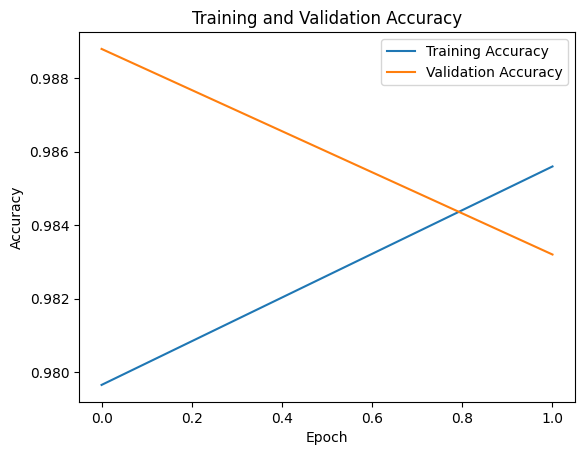

In [13]:

plt.plot(results.history['accuracy'], label='Training Accuracy')
plt.plot(results.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

<B> Evaluerar vår klassificeringsmodell mot testdatasetet

In [14]:
test_loss, test_acc = model.evaluate(test_image_gen)
print(f"Test Accuracy: {test_acc:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 392ms/step - accuracy: 0.9866 - loss: 0.0350
Test Accuracy: 0.9864
